In [1]:
import pandas as pd

df = pd.DataFrame({
    "Gender":["Male","Female","Male","Female","Male","Female","Male","Female","Male","Female"],
    "Category":["Rich","Poor","Middle","Golden","Rich","Poor","Golden","Middle","Rich","Golden"],
    "Age":[45,22,30,55,40,25,60,35,50,28],
    "Payment":["Card","Cash","UPI","Credit","Card","Cash","Credit","UPI","Card","Cash"],
    "Buy":["Yes","No","No","Yes","Yes","No","Yes","No","Yes","No"]
})

print(df)

   Gender Category  Age Payment  Buy
0    Male     Rich   45    Card  Yes
1  Female     Poor   22    Cash   No
2    Male   Middle   30     UPI   No
3  Female   Golden   55  Credit  Yes
4    Male     Rich   40    Card  Yes
5  Female     Poor   25    Cash   No
6    Male   Golden   60  Credit  Yes
7  Female   Middle   35     UPI   No
8    Male     Rich   50    Card  Yes
9  Female   Golden   28    Cash   No


In [2]:
df = pd.get_dummies(df, drop_first=True)

print(df)

   Age  Gender_Male  Category_Middle  Category_Poor  Category_Rich  \
0   45         True            False          False           True   
1   22        False            False           True          False   
2   30         True             True          False          False   
3   55        False            False          False          False   
4   40         True            False          False           True   
5   25        False            False           True          False   
6   60         True            False          False          False   
7   35        False             True          False          False   
8   50         True            False          False           True   
9   28        False            False          False          False   

   Payment_Cash  Payment_Credit  Payment_UPI  Buy_Yes  
0         False           False        False     True  
1          True           False        False    False  
2         False           False         True    False  
3    

In [3]:
X = df.drop("Buy_Yes", axis=1)
y = df["Buy_Yes"]

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

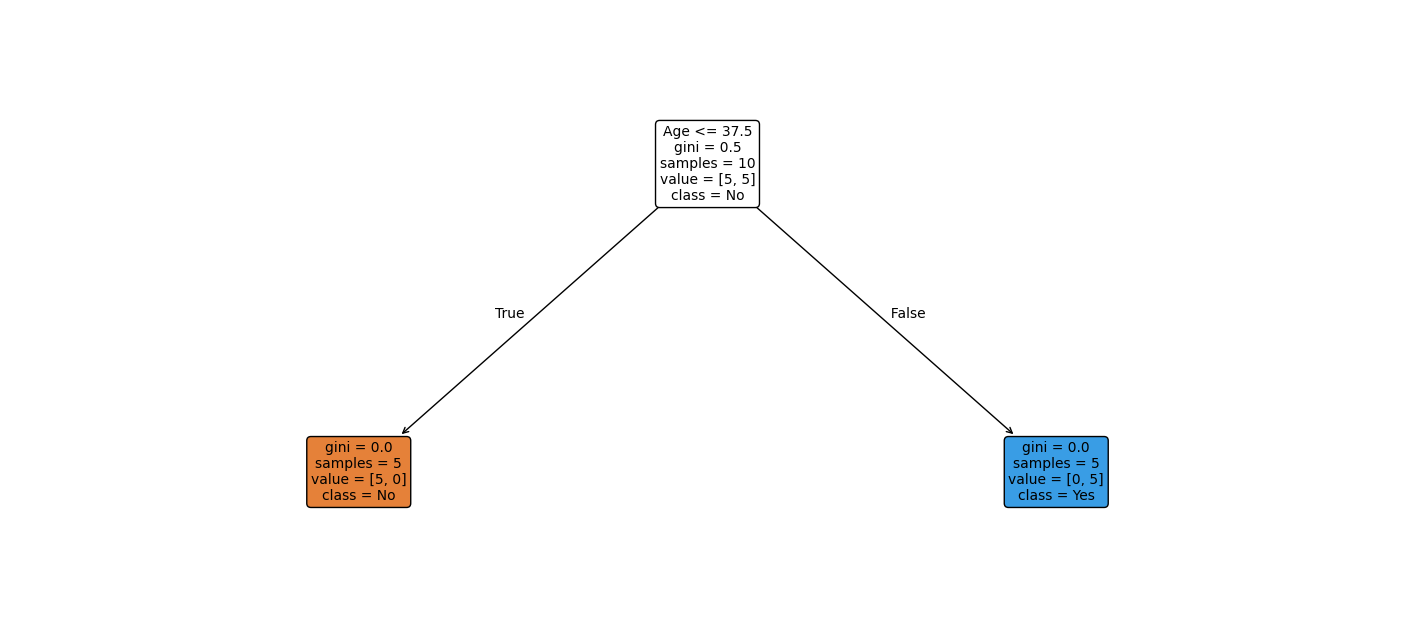

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [6]:
new_customer = pd.DataFrame({
    "Gender":["Male"],
    "Category":["Poor"],
    "Age":[20],
    "Payment":["UPI"]
})

new_customer = pd.get_dummies(new_customer)

# Missing columns add karo
new_customer = new_customer.reindex(columns=X.columns)

prediction = model.predict(new_customer)

print(prediction)

[False]


In [7]:
from sklearn.tree import export_text

print(export_text(model, feature_names=list(X.columns)))

|--- Age <= 37.50
|   |--- class: False
|--- Age >  37.50
|   |--- class: True

